/home/liammyhill/gitLocal/lmyhill/integratedDelta_fullDiscrepancy/venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/liammyhill/gitLocal/lmyhill/integratedDelta_fullDiscrepancy/venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


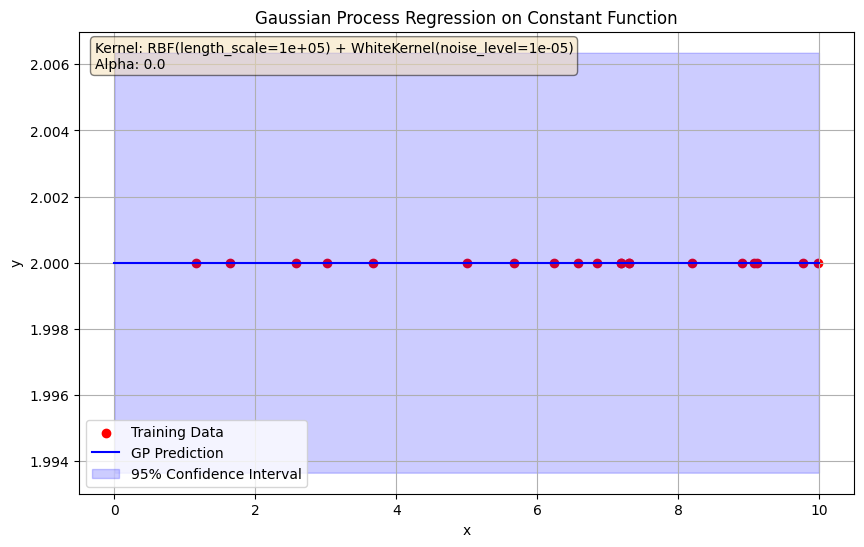

In [1]:
#determine if a scikit-learn gp is capable of learning a constant function y=2 with x in [0,10]
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
# Generate training data
X_train = np.random.uniform(0, 10, 20).reshape(-1, 1)
y_train = np.full(X_train.shape[0], 2.0)
# Define the kernel (RBF + WhiteKernel for noise)
kernel = RBF(length_scale=1.0) + WhiteKernel(noise_level=1e-5)
# Create and fit the Gaussian Process model
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.0)
gp.fit(X_train, y_train)
# Generate test data
X_test = np.linspace(0, 10, 100).reshape(-1, 1)
y_pred, y_std = gp.predict(X_test, return_std=True)
# Plot the results
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='red', label='Training Data')
plt.plot(X_test, y_pred, color='blue', label='GP Prediction')
plt.fill_between(X_test.flatten(), y_pred - 1.96 * y_std, y_pred + 1.96 * y_std, color='blue', alpha=0.2, label='95% Confidence Interval')
plt.title('Gaussian Process Regression on Constant Function')
plt.xlabel('x')
plt.ylabel('y')

# Add hyperparameters to the plot
params_text = f'Kernel: {gp.kernel_}\nAlpha: {gp.alpha}'
plt.text(0.02, 0.98, params_text, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.legend()
plt.grid()
plt.show()


/home/liammyhill/gitLocal/lmyhill/integratedDelta_fullDiscrepancy/venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/liammyhill/gitLocal/lmyhill/integratedDelta_fullDiscrepancy/venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


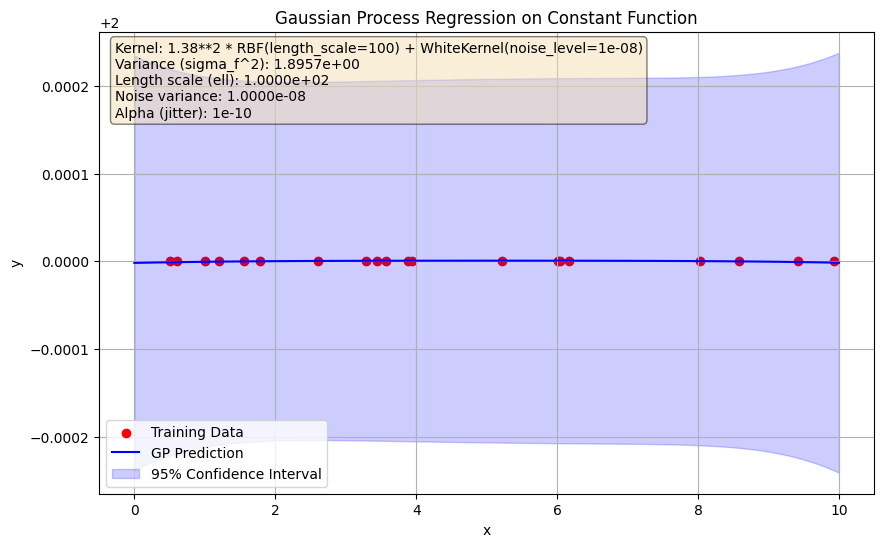

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel

# Generate training data
X_train = np.random.uniform(0, 10, 20).reshape(-1, 1)
y_train = np.full(X_train.shape[0], 2.0)

# Define kernel with explicit variance (ConstantKernel * RBF)
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) \
         + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-8, 1e-1))

# Create and fit the GP model
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10)  # small jitter
gp.fit(X_train, y_train)

# Extract learned hyperparameters
learned_kernel = gp.kernel_
signal_variance = learned_kernel.k1.k1.constant_value
length_scale = learned_kernel.k1.k2.length_scale
noise_variance = learned_kernel.k2.noise_level

# Generate test data
X_test = np.linspace(0, 10, 100).reshape(-1, 1)
y_pred, y_std = gp.predict(X_test, return_std=True)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='red', label='Training Data')
plt.plot(X_test, y_pred, color='blue', label='GP Prediction')
plt.fill_between(
    X_test.flatten(),
    y_pred - 1.96 * y_std,
    y_pred + 1.96 * y_std,
    color='blue',
    alpha=0.2,
    label='95% Confidence Interval'
)

plt.title('Gaussian Process Regression on Constant Function')
plt.xlabel('x')
plt.ylabel('y')

# Add hyperparameters to the plot
params_text = (
    f'Kernel: {learned_kernel}\n'
    f'Variance (sigma_f^2): {signal_variance:.4e}\n'
    f'Length scale (ell): {length_scale:.4e}\n'
    f'Noise variance: {noise_variance:.4e}\n'
    f'Alpha (jitter): {gp.alpha}'
)

plt.text(
    0.02, 0.98, params_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
)

plt.legend()
plt.grid()
plt.show()